# 👥 Facebook-friends dataset — EDA and preprocessing

Copenhagen Networks Study, `fb_friends.csv`: an **undirected edge list**
(`user_a`, `user_b`) of declared Facebook friendships. Unlike `calls`/`sms`,
there is no timestamp or magnitude per row — each row is just a
friendship link.

Steps covered: **(1) duplicates → (2) missing data → (3) outliers → (4)
scaling**, reusing `src/features/eda.py`. This time duplicates uses
`symmetric_duplicate_report`/`drop_symmetric_duplicates`, written
specifically for undirected edge lists (`user_a`–`user_b` == `user_b`–`user_a`),
already used by `tests/test_eda.py`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.data.io import load_facebook_data, write_processed_data
from src.features import eda

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "7267433" / "fb_friends.csv"
%matplotlib inline

In [2]:
data = load_facebook_data(RAW_PATH)
print(data.shape)
data.head()

(6429, 2)


,user_a,user_b
0,0,512
1,0,263
2,0,525
3,0,285
4,0,543


## (1) Duplicates

An edge list needs a different duplicate check than a row-oriented log: the
same friendship can appear as `(a, b)` or `(b, a)` and both mean the same
thing, and a **self-loop** (`user_a == user_b`) is not a friendship at
all.

In [3]:
eda.symmetric_duplicate_report(data, "user_a", "user_b")

{'n_edges': 6429, 'n_self_loops': 11, 'n_duplicate_edges': 0}

**Decision:**

- **Self-loops** (a user linked to themself) are invalid — a friendship
  needs two distinct people — so they are dropped.
- **Duplicate undirected edges** (`(a, b)` and `(b, a)` both present, or the
  exact same pair repeated) — `0` found, so nothing to collapse this time,
  but the dedup path stays wired in for future data refreshes.

In [4]:
data = eda.drop_symmetric_duplicates(data, "user_a", "user_b", drop_self_loops=True)
len(data)

6418

## (2) Missing data

In [5]:
eda.missingness_report(data)

,n_missing,pct_missing
user_a,0,0.0
user_b,0,0.0


**Decision:** 0 missing values in either column — no imputer
needed.

## (3) Outliers

Like `sms.csv`, there is no per-row numeric measurement. The meaningful
signal is **friend count per participant** (graph degree) — the "social
affinity" feature family from the project README. Because the edge list is
undirected, each participant's degree is counted from both `user_a` and
`user_b` occurrences.

In [6]:
degree = (
    pd.concat([data["user_a"], data["user_b"]])
    .value_counts()
    .rename("n_friends")
    .rename_axis("user")
    .reset_index()
)
outlier_bounds = eda.outlier_report_iqr(degree, "n_friends")
outlier_bounds

{'column': 'n_friends',
 'q1': 7.0,
 'q3': 20.25,
 'iqr': 13.25,
 'lower_bound': -12.875,
 'upper_bound': 40.125,
 'n_outliers': 41,
 'pct_outliers': 5.125}

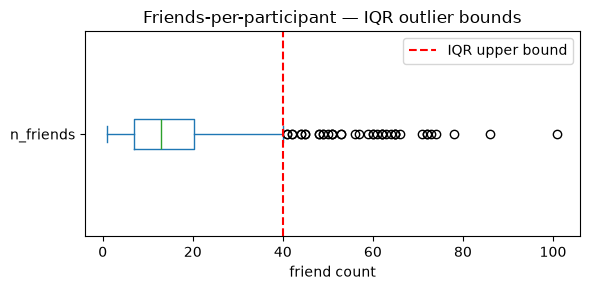

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
degree["n_friends"].plot(kind="box", vert=False, ax=ax)
ax.set_xlabel("friend count")
ax.set_title("Friends-per-participant — IQR outlier bounds")
ax.axvline(outlier_bounds["upper_bound"], color="red", linestyle="--", label="IQR upper bound")
ax.legend()
fig.tight_layout()

**Decision:** ~5% of participants (with declared friendships) are
degree outliers — social "hubs" with up to 101 friends vs. a median of 13.
These are flagged, not removed: a highly-connected participant is a real
and useful structural signal (e.g. for gathering social-affinity features),
not a data error.

In [8]:
outlier_users = eda.flag_outliers_iqr(degree, "n_friends")[["user", "n_friends_outlier"]]
degree = degree.merge(outlier_users, on="user")
degree.sort_values("n_friends", ascending=False).head()

,user,n_friends,n_friends_outlier
0,485,101,True
1,706,86,True
2,13,78,True
3,733,74,True
4,838,73,True


## (4) Scaling

Scale `n_friends` (a magnitude — social-affinity volume) for downstream
models; `user_a`/`user_b` are never scaled since they are anonymous
categorical participant IDs, not measurements. The scaled/flagged degree is
broadcast back onto each edge for both endpoints, so the prepared edge
table carries each participant's own social-activity context.

In [9]:
scaled_degree, degree_scaler = eda.scale_numeric_columns(degree, ["n_friends"], method="robust")

for endpoint in ["user_a", "user_b"]:
    data = data.merge(
        scaled_degree.add_prefix(f"{endpoint}_").rename(columns={f"{endpoint}_user": endpoint}),
        on=endpoint,
        how="left",
    )
data.head()

,user_a,user_b,user_a_n_friends,user_a_n_friends_outlier,user_a_n_friends_scaled,user_b_n_friends,user_b_n_friends_outlier,user_b_n_friends_scaled
0,0,512,19,False,0.45283,45,True,2.415094
1,0,263,19,False,0.45283,71,True,4.377358
2,0,525,19,False,0.45283,28,False,1.132075
3,0,285,19,False,0.45283,14,False,0.075472
4,0,543,19,False,0.45283,35,False,1.660377


## (5)/(6) Balancing & encoding — not applicable here

This is an edge list with no classification target to balance.
`user_a`/`user_b` are anonymous **nominal** participant IDs — encoding them
ordinally would fabricate a ranking between people, so it isn't applied.

## Result

`data` is the prepared dataframe for `fb_friends.csv`:

- Self-loops dropped; duplicate undirected edges deduplicated (0 found this
  time, but the path is exercised for future refreshes).
- 0 true missing values (verified).
- `<endpoint>_n_friends` / `<endpoint>_n_friends_outlier` capture each
  edge endpoint's own friend-count degree and flag social hubs, without
  removing them.
- `<endpoint>_n_friends_scaled` holds each endpoint's median/IQR-scaled
  (`RobustScaler`, chosen because the flagged high-degree "social hubs" are
  kept, not dropped) 
  friend-count degree.

Saved separately from the raw pass-through `fb_friends.parquet` produced by
`main.py`/`export_secondary_datasets`.

In [10]:
output_path = write_processed_data(data, PROJECT_ROOT / "data" / "processed", "fb_friends_prepared.parquet")
output_path

PosixPath('/home/johnny/master_uu/UU-DataMining-2026/data/processed/fb_friends_prepared.parquet')